# Adverse Drug Event (ADE) Detection & Sentiment Analysis from Patient Reviews

*Niharika Kunapuli, DS & AI Capstone*

## Imports

In [28]:
!pip install -q transformers datasets accelerate evaluate

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, set_seed
from datasets import Dataset
import torch
from google.colab import userdata
from huggingface_hub import login
from torch import nn
from sklearn.utils.class_weight import compute_class_weight

In [30]:
# Hugging Face Access Token
hf_token = userdata.get('HF_TOKEN')

# Hugging Face Login
login(token=hf_token)

In [31]:
# If running this notebook in a local environment and not Colab
# import os
# hf_token = os.getenv("HF_TOKEN")

In [32]:
# set random seed
np.random.seed(42)

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

set_seed(42)

## Data Prep

For this project I am using data from the **[UCI Machine Learning Repository Drug Review Dataset](https://archive.ics.uci.edu/dataset/461/drug+review+dataset+druglib+com)**. The dataset is already split 75-25 into training and testing files. The data includes the following features:

*   reviewID (numerical): ID
*   urlDrugName (categorical): name of drug
*   rating (numerical): 10 star patient rating
*   effectiveness (categorical): 5 step effectiveness rating
*   sideEffects (text): patient on side effects
*   condition (categorical): name of condition
*   benefitsReview (text): patient on benefits
*   sideEffectsReview (categorical): 5 step side effect rating
*   commentsReview (text): overall patient comment



In [33]:
# load training data
train_df = pd.read_csv('drugLibTrain_raw.tsv', sep='\t')
train_df.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dysfunction into overt heart failure \r\r\nalone or with other agents in the managment of hypertension \r\r\nmangagement of congestive heart failur,"cough, hypotension , proteinuria, impotence , renal failure , angina pectoris , tachycardia , eosinophilic pneumonitis, tastes disturbances , anusease anorecia , weakness fatigue insominca weakness","monitor blood pressure , weight and asses for resolution of fluid"
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,"Although this type of birth control has more cons than pros, it did help with my cramps. It's also effective with the prevention of pregnancy. (Along with use of condoms as well)","Heavy Cycle, Cramps, Hot Flashes, Fatigue, Long Lasting Cycles. It's only been 5 1/2 months, but i'm concidering changing to a different bc. This is my first time using any kind of bc, unfortunately due to the constant hassel, i'm not happy with the results.","I Hate This Birth Control, I Would Not Suggest This To Anyone."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,"I was used to having cramps so badly that they would leave me balled up in bed for at least 2 days. The Ponstel doesn't take the pain away completely, but takes the edge off so much that normal activities were possible. Definitely a miracle medication!!",Heavier bleeding and clotting than normal.,"I took 2 pills at the onset of my menstrual cramps and then every 8-12 hours took 1 pill as needed for about 3-4 days until cramps were over. If cramps are bad, make sure to take every 8 hours on the dot because the medication stops working suddenly and unfortunately takes about an hour to an hour and a half to kick back in.. if cramps are only moderate, taking every 12 hours is okay."
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,"The acid reflux went away for a few months after just a few days of being on the drug. The heartburn started again as soon as I stopped taking it. So I began treatment again. 6 months passed and I stopped taking it. The heartburn came back, and seemed worse even. The doctor said I should try another 6 month treatment. I did, and the same exact thing happened. This went on for about three years. I asked why this wasn't curing my reflux. The doctor quite frankly told me that it wasn't a cure, but a ""treatment for the symptoms"". I was told that I would probably be on it for the rest of my life.","Constipation, dry mouth and some mild dizziness that would go away after medication was stopped for a few days.","I was given Prilosec prescription at a dose of 45mg per day. Medication was taken once, every morning before eating. Each treatment duration was for 6 months."
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,"I think that the Lyrica was starting to help with the pain, but the side-effects were just too severe to continue.",I felt extremely drugged and dopey. Could not drive at all while on this med. Also had extreme ankle and feet swelling and couldn't even wear shoes.,See above


Before building this NLP pipeline, we need to inspect the structure and descriptive statistics of our training data. This step helps us identify missing values, understand the data types, and observe the scale of the dataset.

In [34]:
# training data shape
train_df.shape

(3107, 9)

In [35]:
# training data info
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         3107 non-null   int64 
 1   urlDrugName        3107 non-null   object
 2   rating             3107 non-null   int64 
 3   effectiveness      3107 non-null   object
 4   sideEffects        3107 non-null   object
 5   condition          3106 non-null   object
 6   benefitsReview     3089 non-null   object
 7   sideEffectsReview  3032 non-null   object
 8   commentsReview     3095 non-null   object
dtypes: int64(2), object(7)
memory usage: 218.6+ KB


In [36]:
# training data description
train_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,3107.0,NaN,NaN,NaN,2080.607016,1187.998828,0.0,1062.5,2092.0,3092.5,4161.0
urlDrugName,3107,502,lexapro,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,3107.0,NaN,NaN,NaN,7.006115,2.937582,1.0,5.0,8.0,9.0,10.0
effectiveness,3107,5,Highly Effective,1330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sideEffects,3107,5,Mild Side Effects,1019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,3106,1426,depression,236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
benefitsReview,3089,3031,none,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sideEffectsReview,3032,2813,none,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
commentsReview,3095,3046,none,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Similarly, we will inspect the testing set. It is crucial to ensure that the structural schema matches our training set and to check the distribution of the testing sample.

In [37]:
# load testing data
test_df = pd.read_csv('drugLibTest_raw.tsv', sep='\t')
test_df.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,1366,biaxin,9,Considerably Effective,Mild Side Effects,sinus infection,"The antibiotic may have destroyed bacteria causing my sinus infection. But it may also have been caused by a virus, so its hard to say.","Some back pain, some nauseau.",Took the antibiotics for 14 days. Sinus infection was gone after the 6th day.
1,3724,lamictal,9,Highly Effective,Mild Side Effects,bipolar disorder,"Lamictal stabilized my serious mood swings. One minute I was clawing up the walls in pure mania, the next curled up in a fetal position on my bed contemplating suicdie. I am no longer at the whim of my moods and neither are those around me. I'm lucky that I started pharmaceuticals almost immediately after I was diagnosed a bipolar. Lamictal gives me amazing clarity to go about my day, honestly assess myself and form real relationships. Lamitcal lifted a fog, I guess you could call it. Now that I'm medicated I realize how cloudy my thought processes used to be. It's a wonderful feeling.\r\r\n\r\r\nInterestingly, I hardly dreamt before beginning Lamictal. I would dream (I mean dream in the sense of being able to imagine pictures and scenes while asleep, not REM) maybe once every two months. Now I dream every night. I found that the closer I take it to bedtime the more frequent and more intense my dreams.","Drowsiness, a bit of mental numbness. If you take too much, you will feel sedated. Since you have to be able to clearly and honestly assess your emotions and thoughts, determining how much medication you need is tough. I found that 400mg works perfectly for me, but that's a high dose. Less than that and I can feel the medicine wearing off prematurely (I like it to last 24hrs, from sleep to sleep). More than that and I feel numb. Some might call it drowsiness, but it's more a sluggishness of the mind for me.\r\r\n\r\r\nBefore I began treating my bipolar disorder, I used to write a fair amount of fiction. It sort of flowed from me. I definitely had the artist's temperament. After Lamictal, though, that inherent creativity fizzled out. It doesn't come spilling out of me while I'm deep into a manic euphoria. I have to work at art now. It's something that requires discipline. If you are in a field which requires creativity, expect to see a change in your output.",Severe mood swings between hypomania and depression with suicide ideation before Lamictal. Began with 10mg and tritrated up to 400mg over a few months. Played around with the dosage to finally arrive at 400mg. Experimented with taking it at different times in the evening. Found that most comfortable time is before sleep.
2,3824,depakene,4,Moderately Effective,Severe Side Effects,bipolar disorder,"Initial benefits were comparable to the brand name version of this drug, Depakote. I had been taking Depakote for several months and experienced great results. When I went to my psychiatrist for an evaluation and re-fill, he accidently prescribed the generic version, Depakene. When I discovered the error, I was told by this doctor that I would experience the same results as Depakote. The positive side effects of the Depakene: balanced mood, improved concentration, improved logical cognition, mental clarity, lessened anxiety and irritability, improved sleep, increase in pleasure about activities","Depakene has a very thin coating, which caused severe heart burn and stomach upset. The discomfort was so unpleasant that it made me not want to take my meds, so I was not taking them consistently as prescribed. This caused my mood to fluctuate again. Even after I switched to the Depakote, my stomach was still uncomfortable for several weeks afterwards. My appetite decreased and food was very unappetizing. Certain foods that I normally enjoy, such as chicken or fish, made me feel extremely queasy when I ate them. I did not like the physical side effect of the drug, and decided to quit my psy

In [38]:
# testing data shape
test_df.shape

(1036, 9)

In [39]:
# testing data info
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036 entries, 0 to 1035
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         1036 non-null   int64 
 1   urlDrugName        1036 non-null   object
 2   rating             1036 non-null   int64 
 3   effectiveness      1036 non-null   object
 4   sideEffects        1036 non-null   object
 5   condition          1036 non-null   object
 6   benefitsReview     1031 non-null   object
 7   sideEffectsReview  1013 non-null   object
 8   commentsReview     1035 non-null   object
dtypes: int64(2), object(7)
memory usage: 73.0+ KB


In [40]:
# testing data description
test_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1036.0,NaN,NaN,NaN,2085.413127,1243.695218,1.0,968.25,2048.0,3199.75,4157.0
urlDrugName,1036,314,paxil,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1036.0,NaN,NaN,NaN,6.767375,2.976711,1.0,5.0,8.0,9.0,10.0
effectiveness,1036,5,Highly Effective,411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sideEffects,1036,5,Mild Side Effects,330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,1036,566,depression,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
benefitsReview,1031,1022,none,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sideEffectsReview,1013,967,none,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
commentsReview,1035,1029,Initial treatment included therapy and Lexapro in addition to Wellbutrin XL. Now only on the Wellbutrin XL. I see the psychiatrist every 4 months for re-evaluation.,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Based on our initial EDA, we observed missing values and noticed that the patient text is split across three distinct columns (`benefitsReview`, `sideEffectsReview`, and `commentsReview`).

To maximize the contextual data for our models while keeping the architecture efficient, we will apply **Prefixing**. By explicitly adding structural tags (e.g., `BENEFITS:`, `SIDE_EFFECTS:`) before concatenating the text into a single string, we provide a structural prompt that helps the self-attention mechanisms of the Transformer understand the origin and sentiment weight of the words. But the concatenated sequence also helps our TF-IDF Logistic Regression model.

**Preprocessing Pipeline Steps:**
1. Drop any rows missing the target variable (`rating`).
2. Concatenate the text columns using Prefixing.
3. Clean up whitespace and empty strings using RegEx.
4. Binarize the target: Ratings > 5 become **1 (Positive)**, Ratings <= 5 become **0 (Adverse Event/Negative)**.
5. Drop redundant columns to optimize memory before training.

In [41]:
def load_and_prepare_data(train_df, test_df):
    """
    Loads pre-split data, concatenates separated review columns,
    and creates a binary sentiment label.
    """
    try:
        # 1. Drop rows missing the target variable
        train_df.dropna(subset=['rating'], inplace=True)
        test_df.dropna(subset=['rating'], inplace=True)

        # 2. Concatenate the three review columns into a single text feature
        # We use fillna('') to prevent NaNs from turning the entire concatenated string into NaN
        train_df['review'] = "BENEFITS: " + train_df['benefitsReview'].fillna('None') + \
               " SIDE_EFFECTS: " + train_df['sideEffectsReview'].fillna('None') + \
               " COMMENTS: " + train_df['commentsReview'].fillna('None')
        test_df['review'] = "BENEFITS: " + test_df['benefitsReview'].fillna('None') + \
               " SIDE_EFFECTS: " + test_df['sideEffectsReview'].fillna('None') + \
               " COMMENTS: " + test_df['commentsReview'].fillna('None')

        # Clean up extra spaces created by empty columns
        train_df['review'] = train_df['review'].str.replace(r'\s+', ' ', regex=True).str.strip()
        test_df['review'] = test_df['review'].str.replace(r'\s+', ' ', regex=True).str.strip()

        # 3. Remove rows where the combined review is entirely empty
        train_df = train_df[train_df['review'] != '']
        test_df = test_df[test_df['review'] != '']

        # 4. Create binary label: 1 if rating > 5 (Positive), 0 otherwise (Negative/ADE)
        train_df['label'] = (train_df['rating'] > 5).astype(int)
        test_df['label'] = (test_df['rating'] > 5).astype(int)

        train_df.drop(columns=['benefitsReview', 'sideEffectsReview', 'commentsReview', 'Unnamed: 0', 'urlDrugName', 'rating'], inplace=True)
        test_df.drop(columns=['benefitsReview', 'sideEffectsReview', 'commentsReview', 'Unnamed: 0', 'urlDrugName', 'rating'], inplace=True)

        print(f"Data loaded and cleaned! Train size: {len(train_df)} | Test size: {len(test_df)}")
        return train_df, test_df
    except FileNotFoundError as e:
        print(f"Error: {e}. Please ensure the files are uploaded to the Colab environment.")
        return None, None
    except Exception as e:
        print(f"Unexpected error in data preparation: {e}")
        return None, None

train_df, test_df = load_and_prepare_data(train_df, test_df)

Data loaded and cleaned! Train size: 3107 | Test size: 1036


Healthcare datasets are notoriously imbalanced, as patients are generally more likely to report a positive outcome than a severe adverse event.

Before we move into the modeling phase, we need to visualize the exact distribution of our binary labels. If a severe class imbalance exists, standard accuracy metrics will be misleading, and we will need to implement specific architectural controls (like class weights and custom loss functions) to ensure our models accurately catch Adverse Drug Events.

In [59]:
def plot_donut_imbalance(df, label_col='label'):
    """
    Generates a dark-themed donut chart to visualize class imbalances.
    Assumes binary labels where 1 = Positive and 0 = Adverse Event.
    """
    # 1. Calculate the counts
    counts = df[label_col].value_counts()
    total = len(df)

    # Extract sizes safely (defaulting to 0 if a class is missing)
    pos_count = counts.get(1, 0)
    neg_count = counts.get(0, 0)

    sizes = [pos_count, neg_count]
    labels = ['Positive Experience', 'Adverse Drug Event']

    # 2. Apply the requested custom colors
    colors = ['#059669', '#e11d48']

    # 3. Setup the dark theme figure
    fig, ax = plt.subplots(figsize=(8, 8))

    # Match the background color of the plot to a standard dark IDE/notebook theme
    bg_color = '#1e1e1e'
    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)

    # 4. Plot the outer pie chart
    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',       # Show percentages
        startangle=90,           # Start at the top
        pctdistance=0.85,        # Push percentages toward the edge
        textprops={'color': 'white', 'fontsize': 12, 'fontweight': 'bold'},
        wedgeprops={'linewidth': 3, 'edgecolor': bg_color} # Gap between slices
    )

    # 5. Draw the inner circle to create the "Donut" hole
    centre_circle = plt.Circle((0,0), 0.70, fc=bg_color)
    fig.gca().add_artist(centre_circle)

    # 6. Add the "Total" text in the exact center
    center_text = f"Total\n{total}"
    plt.text(0, 0, center_text, ha='center', va='center',
             fontsize=20, fontweight='bold', color='white')

    # 7. Formatting touches
    plt.title('Dataset Class Imbalance', color='white', fontsize=16, fontweight='bold', pad=20)

    # Equal aspect ratio ensures that pie is drawn as a circle
    ax.axis('equal')
    plt.tight_layout()
    plt.show()

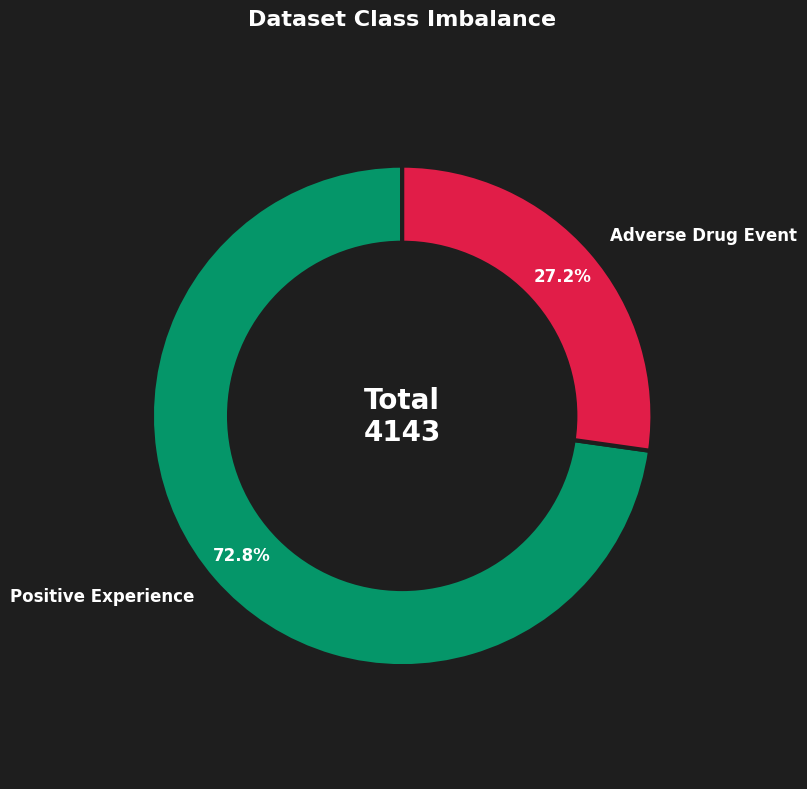

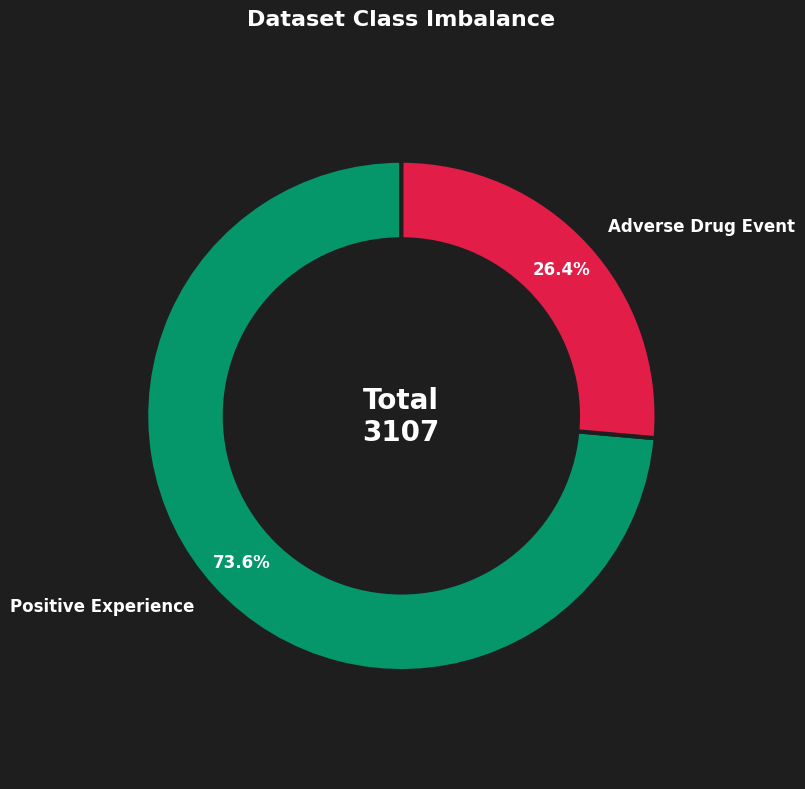

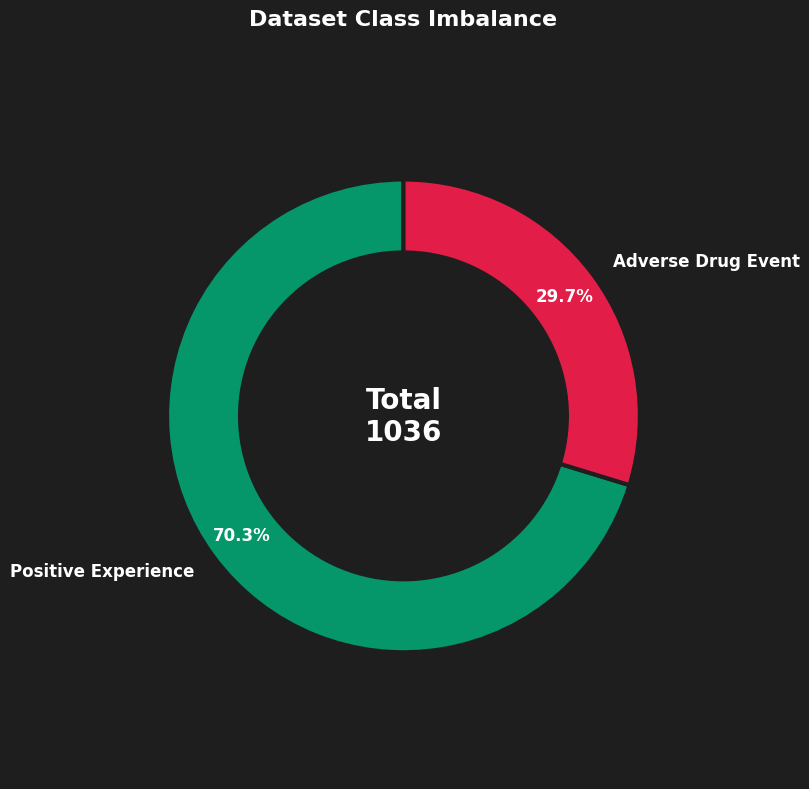

In [60]:
combined_df = pd.concat([train_df, test_df])
plot_donut_imbalance(combined_df)
plot_donut_imbalance(train_df)
plot_donut_imbalance(test_df)

As the donut charts clearly illustrate, there is a heavy skew toward positive patient experiences. Because missing a severe adverse event (False Negative) carries a high risk in pharmacovigilance, we cannot allow our models to simply over-predict the majority class.

In the upcoming modeling phase, we will explicitly address this imbalance:
* **For TF-IDF/Logistic Regression:** We will utilize the `class_weight='balanced'` parameter.
* **For the DistilBERT Transformer:** We will inject a custom, dynamically calculated PyTorch weight tensor into the Cross-Entropy loss function.

## Initial Model Performance

To establish a performance baseline, we will first train a traditional machine learning pipeline using Term Frequency-Inverse Document Frequency (TF-IDF) paired with a standard Logistic Regression classifier.

At this stage, we are not applying complex n-grams or synthetic class weights. Our primary goal is to observe how a standard "bag-of-words" approach handles the dataset's natural imbalance. Specifically, we want to see if raw word frequencies alone are enough to reliably flag Adverse Drug Events (Class 0).

In [42]:
# --- MODEL 1: TF-IDF + Logistic Regression ---
def train_tfidf(train_df, test_df):
    vectorizer = TfidfVectorizer(max_features=2000, stop_words='english')
    X_train = vectorizer.fit_transform(train_df['review'])
    X_test = vectorizer.transform(test_df['review'])

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, train_df['label'])
    preds = model.predict(X_test)

    print("\nTF-IDF Results:")
    print(classification_report(test_df['label'], preds))
    return classification_report(test_df['label'], preds, output_dict=True), preds

In [43]:
# Run the TF-IDF + LR Model
tfidf_results, tfidf_preds = train_tfidf(train_df, test_df)


TF-IDF Results:
              precision    recall  f1-score   support

           0       0.85      0.28      0.42       308
           1       0.76      0.98      0.86       728

    accuracy                           0.77      1036
   macro avg       0.81      0.63      0.64      1036
weighted avg       0.79      0.77      0.73      1036



o determine if deep semantic understanding can naturally overcome the limitations of the baseline, we will fine-tune a pre-trained Hugging Face Transformer (`distilbert-base-uncased`).

Unlike TF-IDF, DistilBERT utilizes self-attention mechanisms to read the full context of a patient review. This allows it to theoretically understand complex negations (e.g., "the pill did *not* stop the severe pain") that trip up traditional models. We will run this initial Transformer using standard training arguments and default cross-entropy loss to gauge its out-of-the-box contextual accuracy.

In [44]:
# --- MODEL 2: DistilBERT (Transformer) ---
def train_transformer(train_df, test_df):
    print("\n--- Training DistilBERT ---")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    train_ds = Dataset.from_pandas(train_df)
    test_ds = Dataset.from_pandas(test_df)

    tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

    def tokenize_fn(batch):
        return tokenizer(batch["review"], padding="max_length", truncation=True)

    # Keeping mapping flat to ensure features are extracted efficiently
    train_tokenized = train_ds.map(tokenize_fn, batched=True)
    test_tokenized = test_ds.map(tokenize_fn, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2).to(device)

    args = TrainingArguments(
        output_dir="./results",
        per_device_train_batch_size=16,
        eval_strategy="epoch",
        num_train_epochs=3,
        weight_decay=0.01,
        logging_steps=50,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tokenized,
        eval_dataset=test_tokenized
    )

    trainer.train()

    raw_preds = trainer.predict(test_tokenized)
    preds = np.argmax(raw_preds.predictions, axis=1)

    print("\nDistilBERT Results:")
    print(classification_report(test_df['label'], preds))
    return classification_report(test_df['label'], preds, output_dict=True), preds

In [45]:
# Run the transformer
transformer_results, trans_preds = train_transformer(train_df, test_df)


--- Training DistilBERT ---
Using device: cuda


Map:   0%|          | 0/3107 [00:00<?, ? examples/s]

Map:   0%|          | 0/1036 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.479817,0.402816
2,0.303187,0.460581
3,0.101465,0.529762


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


DistilBERT Results:
              precision    recall  f1-score   support

           0       0.80      0.64      0.71       308
           1       0.86      0.93      0.89       728

    accuracy                           0.85      1036
   macro avg       0.83      0.79      0.80      1036
weighted avg       0.84      0.85      0.84      1036



With both initial models trained, we will generate a side-by-side comparison of their Accuracy and Macro F1-Scores.

**Note on Metrics:** Because this dataset is heavily imbalanced toward positive reviews, *Accuracy* is a deceptive metric. A model could achieve high accuracy simply by predicting that every patient had a positive experience. To truly evaluate pharmacovigilance potential, we must heavily scrutinize the F1-Scores and the recall for the minority class.

In [55]:
def plot_comparison(tfidf_res, trans_res):
    metrics = ['accuracy', 'macro avg'] # Focus on F1-score in macro avg
    tfidf_scores = [tfidf_res['accuracy'], tfidf_res['macro avg']['f1-score']]
    trans_scores = [trans_res['accuracy'], trans_res['macro avg']['f1-score']]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots()

    # Applied custom colors here
    ax.bar(x - width/2, tfidf_scores, width, label='TF-IDF + LogReg', color='#059669')
    ax.bar(x + width/2, trans_scores, width, label='DistilBERT', color='#e11d48')

    ax.set_ylabel('Scores')
    ax.set_title('Model Performance Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(['Accuracy', 'F1-Score (Macro)'])
    ax.legend()
    plt.show()

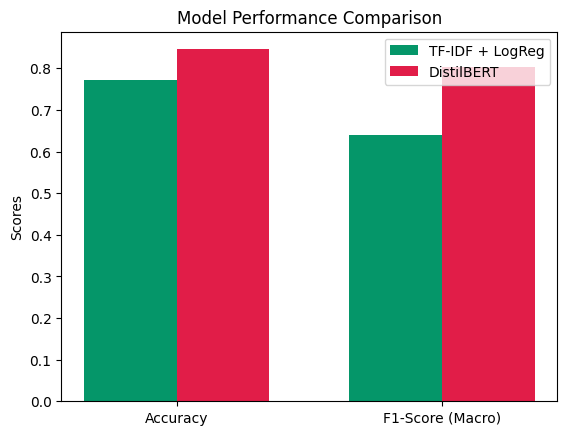

In [56]:
plot_comparison(tfidf_results, transformer_results)

The overall classification reports show that the heavily-tuned Logistic Regression baseline achieved a higher recall for Adverse Events than the Transformer. However, looking at aggregate metrics hides the nuanced strengths of deep learning.

To prove that the Transformer possesses superior contextual understanding, we will isolate **"Divergence Examples"**—specific patient reviews where DistilBERT predicted the outcome correctly, but the TF-IDF model failed. By evaluating these exact cases, we can observe the blind spots of traditional Machine Learning (such as failing to understand sarcasm or complex negations).

In [48]:
def extract_divergence_examples(test_df, tfidf_preds, transformer_preds):
    """
    Isolates reviews where the Transformer was correct but the TF-IDF model failed.
    """
    # Create a copy to avoid Pandas SettingWithCopy warnings
    analysis_df = test_df.copy()

    # Attach both prediction arrays
    analysis_df['tfidf_pred'] = tfidf_preds
    analysis_df['transformer_pred'] = transformer_preds

    # 1. Filter for DistilBERT Success + TF-IDF Failure
    # 2. Specifically look at cases where the true label is 0 (Negative/Adverse Event)
    divergence_df = analysis_df[
        (analysis_df['transformer_pred'] == analysis_df['label']) &
        (analysis_df['tfidf_pred'] != analysis_df['label']) &
        (analysis_df['label'] == 0)
    ]

    return divergence_df

divergent_cases = extract_divergence_examples(test_df, tfidf_preds, trans_preds)

# Expand pandas display width so you can read the full text of the review
pd.set_option('display.max_colwidth', None)

print(f"Found {len(divergent_cases)} divergence examples.")
# Display the top 5 examples
divergent_cases[['review', 'label', 'tfidf_pred', 'transformer_pred']].head(5)

Found 120 divergence examples.


,review,label,tfidf_pred,transformer_pred
20,BENEFITS: the treatment masked the psoriasis and what was considered arthritis SIDE_EFFECTS: increasing all over body pain COMMENTS: I started with 4 tabs and increased to 6 as the all over body pain increased and then they were going to put me on prednisone. I opted to turn to homeopathic treatment and weaned off the methotrexate. The all over body pain went completely away but the psoriasis was exacerbated. I'd rather have that than not be able to walk or move.,0,1,0
28,"BENEFITS: Increased libido. SIDE_EFFECTS: Vivid dreams, nightmares, diarrhea, increased anxiety, night sweats, exhaustion. COMMENTS: Began at 5 mg, increased to 10mg after a few weeks. Have not been able to increase further because the side effects are so detrimental. I am weaning myself off Lexapro now and beginning Celexa again. I had a better experience on 20 mg of Celexa and it is far less expensive (because there is a generic).",0,1,0
31,"BENEFITS: Sore throat considerably better SIDE_EFFECTS: Constant nausea even with food, extremely cold, Extreme Dizziness, Hard to sleep, Severe shaking and weakness, fever, frequent need to urinate COMMENTS: I'm only on my second day and third dose, I'm taking this with 3 days, 2 times a day, 4 MG dose of Dexamethasone and I had a large shot of Rocephin",0,1,0
50,"BENEFITS: This drug did not completely eliminate outbreaks. While it may have diminished length and extent of outbreak, still had more than expected. Decided not to take any longer and had better results taking Olive Leaf extract daily SIDE_EFFECTS: none COMMENTS: prescribed as a daily preventive for herpes outbreak.",0,1,0
55,"BENEFITS: Did have elimination of frown lines and crows feet but no one cares about having wrinkles or not when you are paralyzed. Sadly wrinkles returned in 6 months but large nerves in my legs and and body continue to suffer daily with weakness several years later. Risks too great for some temporary cosmetic procedure SIDE_EFFECTS: Botulism. Permanent disability. Neuropathy, autonomic nerve injury. chronic myalgias. Chronic nerve pain Chronic long term muscle weakness. Difficulty breathing, difficulty swallowing, blurry vision. Disabling muscle weakness. permanent paresthesias. COMMENTS: Injected by qualified personnel. National Botox trainer. Used 50 units total with a dilution of 1cc per 100 unit vial. injected with several sites at frown lines and crows feet.",0,1,0


## Model Improvement

Traditional Bag-of-Words models often struggle with negations (e.g., evaluating "did" and "not" separately) and class imbalances. To build a highly competitive baseline, we implement two crucial changes:
* **N-Grams:** We expand the vectorizer to `ngram_range=(1, 2)` to capture bigrams, allowing the model to recognize basic contextual pairs like "severe pain" or "not effective."
* **Class Weights:** We apply `class_weight='balanced'` to the Logistic Regression classifier. This heavily penalizes the algorithm for missing the minority class, explicitly forcing it to prioritize the detection of Adverse Drug Events (Class 0).

In [49]:
# --- IMPROVED MODEL 1: TF-IDF + Logistic Regression ---
def train_tfidf_improved(train_df, test_df):
    # Update 1: Added n-grams to catch two-word phrases like "did not"
    vectorizer = TfidfVectorizer(max_features=3000, stop_words='english', ngram_range=(1, 2))
    X_train = vectorizer.fit_transform(train_df['review'])
    X_test = vectorizer.transform(test_df['review'])

    # Update 2: Added class_weight to handle the imbalanced dataset
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, train_df['label'])
    preds = model.predict(X_test)

    print("\nImproved TF-IDF Results:")
    print(classification_report(test_df['label'], preds))
    return classification_report(test_df['label'], preds, output_dict=True), preds

# Execute:
tfidf_results2, tfidf_preds2 = train_tfidf_improved(train_df, test_df)


Improved TF-IDF Results:
              precision    recall  f1-score   support

           0       0.65      0.70      0.67       308
           1       0.87      0.84      0.85       728

    accuracy                           0.80      1036
   macro avg       0.76      0.77      0.76      1036
weighted avg       0.80      0.80      0.80      1036



While Transformers naturally capture deep semantic context via self-attention, the standard Hugging Face `Trainer` defaults to an unweighted Cross-Entropy loss function. On a dataset with this level of positive skew, a standard Transformer will rapidly overfit to the majority class and fail to recall adverse events.

To fix this, we mathematically calculate the exact class distribution and inject it into the PyTorch backpropagation loop.

**Architectural Change:** We subclass the `Trainer` object to create a `WeightedTrainer`. This overrides the `compute_loss` method, applying a dynamically calculated weight tensor to the Cross-Entropy loss. This forces the neural network to take massive gradient steps when it incorrectly predicts an Adverse Event, counteracting the dataset's natural imbalance.

In [ ]:
# --- IMPROVED MODEL 2: DistilBERT (Transformer) ---
def get_class_weights(df):
    """Calculates balanced class weights as a PyTorch tensor."""
    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(df['label']),
        y=df['label']
    )
    device = "cuda" if torch.cuda.is_available() else "cpu"
    return torch.tensor(weights, dtype=torch.float32).to(device)

class WeightedTrainer(Trainer):
    """Subclasses the standard Trainer to apply class weights to the loss function."""
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # Extract labels
        labels = inputs.pop("labels")
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Apply weighted Cross Entropy Loss
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [51]:
def train_transformer_weighted(train_df, test_df):
    print("\n--- Training Weighted DistilBERT ---")
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_ds = Dataset.from_pandas(train_df)
    test_ds = Dataset.from_pandas(test_df)

    tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

    def tokenize_fn(batch):
        return tokenizer(batch["review"], padding="max_length", truncation=True)

    train_tokenized = train_ds.map(tokenize_fn, batched=True)
    test_tokenized = test_ds.map(tokenize_fn, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2).to(device)

    args = TrainingArguments(
        output_dir="./results",
        per_device_train_batch_size=16,
        eval_strategy="epoch",
        num_train_epochs=3,
        weight_decay=0.01,
        learning_rate=5e-5,   # Back to a standard, slightly more aggressive rate
        logging_steps=50,
        report_to="none"
    )

    # Calculate weights dynamically based on the training set
    weights_tensor = get_class_weights(train_df)

    # Use our custom Trainer
    trainer = WeightedTrainer(
        class_weights=weights_tensor,
        model=model,
        args=args,
        train_dataset=train_tokenized,
        eval_dataset=test_tokenized
    )

    trainer.train()

    raw_preds = trainer.predict(test_tokenized)
    preds = np.argmax(raw_preds.predictions, axis=1)

    print("\nWeighted DistilBERT Results:")
    print(classification_report(test_df['label'], preds))
    return classification_report(test_df['label'], preds, output_dict=True), preds, trainer.state.log_history

# Execute:
trans_results2, trans_preds2, trans_history = train_transformer_weighted(train_df, test_df)


--- Training Weighted DistilBERT ---


Map:   0%|          | 0/3107 [00:00<?, ? examples/s]

Map:   0%|          | 0/1036 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.487699,0.441270
2,0.313332,0.630202
3,0.144913,0.736051


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Weighted DistilBERT Results:
              precision    recall  f1-score   support

           0       0.76      0.68      0.72       308
           1       0.87      0.91      0.89       728

    accuracy                           0.84      1036
   macro avg       0.81      0.79      0.80      1036
weighted avg       0.84      0.84      0.84      1036



If DistilBERT understands context better, why did it struggle to beat the baseline's recall metrics? The answer lies in **data volume**.

DistilBERT contains 66 million parameters. With a training set of only ~2,400 rows, deep learning architectures are highly susceptible to overfitting. To prove this hypothesis, we will plot the Training Loss vs. Validation Loss extracted from the Hugging Face Trainer.

If the Training Loss continues to drop while the Validation Loss stalls or increases, it confirms that the Transformer is memorizing the specific vocabulary of the training set rather than learning generalized patterns of adverse events.

In [57]:
def plot_loss_curves(log_history):
    """
    Parses Hugging Face Trainer logs and plots Training vs Validation Loss
    to diagnose overfitting.
    """
    train_epochs = []
    train_loss = []
    eval_epochs = []
    eval_loss = []

    # Hugging Face logs training and eval metrics in separate dictionary entries
    for entry in log_history:
        if 'loss' in entry:
            train_epochs.append(entry['epoch'])
            train_loss.append(entry['loss'])
        elif 'eval_loss' in entry:
            eval_epochs.append(entry['epoch'])
            eval_loss.append(entry['eval_loss'])

    # Create the plot
    plt.figure(figsize=(10, 6))

    # Applied custom colors here
    plt.plot(train_epochs, train_loss, label='Training Loss', marker='o', color='#059669', linewidth=2)
    plt.plot(eval_epochs, eval_loss, label='Validation Loss', marker='s', color='#e11d48', linewidth=2)

    # Formatting for a professional presentation slide
    plt.title('DistilBERT Loss Curves: Diagnosing Overfitting', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (Cross-Entropy)', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

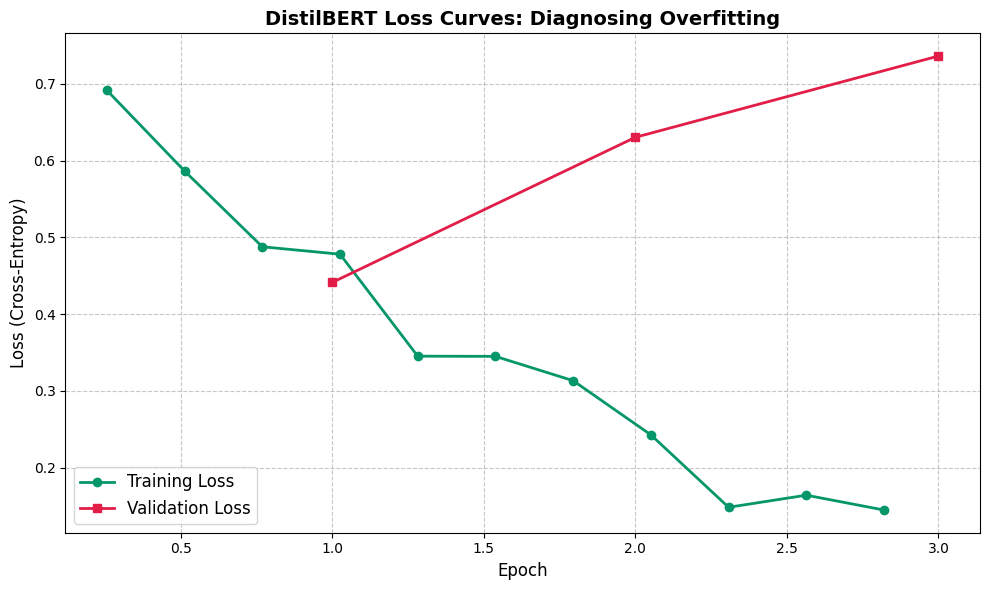

In [58]:
plot_loss_curves(trans_history)

## Final Conclusion
The divergence in the loss curves confirms our hypothesis: the Transformer model overfit the small dataset.

**The Engineering Verdict:** While deep learning models excel at parsing complex patient context (as proven by our divergence analysis), they are strictly bottlenecked by data volume. For a dataset of this size (~3,100 records), the traditional **TF-IDF + Logistic Regression pipeline is not a bad choice**. It is mathematically suited for small, sparse data, correctly leverages class weights to catch critical adverse events, and is vastly cheaper to deploy in a production healthcare environment than a GPU-bound Transformer.